In [1]:
import numpy as np
import matplotlib.pyplot as plt
import datasets
from privacy_estimates.experiments.aml import JobList
from sklearn.metrics import roc_curve, roc_auc_score, auc

/anaconda/envs/privacy-estimates/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## (1) Do this for one job. 

Quite simple: how can I just compute the AUC and tpr at low FPR for just one job? 

In [28]:
def compute_performance(scores_members, scores_non_members):
    mia_performance = {}
    
    member_vals = [val for val in scores_members]
    non_member_vals = [val for val in scores_non_members]
    mia_performance['auc'] = roc_auc_score([1]*len(member_vals) + [0]*len(non_member_vals), member_vals + non_member_vals)
    fpr, tpr, thresholds = roc_curve([1]*len(member_vals) + [0]*len(non_member_vals), member_vals + non_member_vals)
    for target_fpr in (0.01, 0.05, 0.1):
        mia_performance[f'tpr_at_{target_fpr}'] = np.interp(target_fpr, fpr, tpr)
    print(f"AUC: {mia_performance['auc']}, TPR@0.01: {mia_performance['tpr_at_0.01']}, TPR@0.05: {mia_performance['tpr_at_0.05']}, TPR@0.1: {mia_performance['tpr_at_0.1']}")

    # also add the curves
    mia_performance['fpr'] = fpr
    mia_performance['tpr'] = tpr

    return mia_performance

In [29]:
# paste the url of the (completed) target job here

jobs = JobList.from_urls([
    'https://ml.azure.com/runs/calm_honey_k70j459lks?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourceGroups/ppml/providers/Microsoft.MachineLearningServices/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47#'])

In [30]:
# download the corresponding scores and challenge bits
# Note that this faisl when the target directory already exists, so always use a new name for each job (or remove the old results)

job_name = 'JOB_NAME'
test = jobs[0].get_node('estimate_privacy').download_input('scores', f'./mia_results/{job_name}/scores')
test = jobs[0].get_node('estimate_privacy').download_input('challenge_bits', f'./mia_results/{job_name}/challenge_bits')

In [31]:
scores = datasets.load_from_disk(f'./mia_results/{job_name}/scores')
bits = datasets.load_from_disk(f'./mia_results/{job_name}/challenge_bits')
scores[0], bits[0]

({'score': 1.0657628449776577}, {'challenge_bit': 1})

AUC: 0.574856671907694, TPR@0.01: 0.021696252465483234, TPR@0.05: 0.09664694280078895, TPR@0.1: 0.14792899408284024


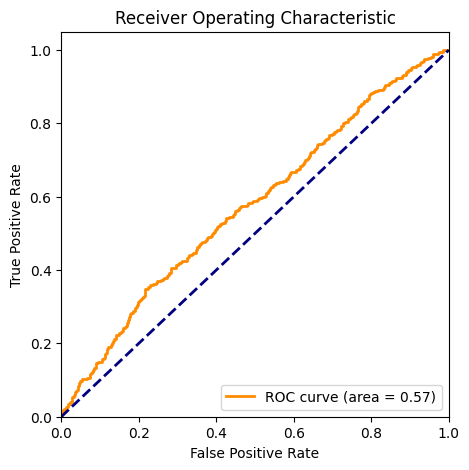

In [32]:
membership_scores = np.array([k['score'] for k in scores])
membership_labels = np.array([k['challenge_bit'] for k in bits])
members = membership_scores[membership_labels == 1]
non_members = membership_scores[membership_labels == 0]

# compute performance
performance = compute_performance(members, non_members)

fpr, tpr = performance['fpr'], performance['tpr']
roc_auc = performance['auc']

# Plot ROC curve
plt.figure(figsize = (5, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [34]:
# let's also make a function that computes the performance directly from the url

from datetime import datetime

def compute_performance_from_url(url, job_name = None):
    jobs = JobList.from_urls([url])
    if job_name is None:
        job_name = str(datetime.now())
    
    if not os.path.exists(f'./mia_results/{job_name}'):
        test = jobs[0].get_node('estimate_privacy').download_input('scores', f'./mia_results/{job_name}/scores')
        test = jobs[0].get_node('estimate_privacy').download_input('challenge_bits', f'./mia_results/{job_name}/challenge_bits')
    scores = datasets.load_from_disk(f'./mia_results/{job_name}/scores')
    bits = datasets.load_from_disk(f'./mia_results/{job_name}/challenge_bits')
    
    membership_scores = np.array([k['score'] for k in scores])
    membership_labels = np.array([k['challenge_bit'] for k in bits])
    members = membership_scores[membership_labels == 1]
    non_members = membership_scores[membership_labels == 0]
    return compute_performance(members, non_members)

performance = compute_performance_from_url('https://ml.azure.com/runs/calm_honey_k70j459lks?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourceGroups/ppml/providers/Microsoft.MachineLearningServices/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47#')

AUC: 0.574856671907694, TPR@0.01: 0.021696252465483234, TPR@0.05: 0.09664694280078895, TPR@0.1: 0.14792899408284024


## (2) Do this across jobs submitted using a bash script

I just launched a series of jobs using a bash script and I wrote the job output to a txt file. How can I easily compute the MIA performance for all results? 

Imagine I ran: `./launch_synthetic_mias.sh > all_synthetic_jobs.txt > ./agnews_nrep16_allsynth.txt`

In [35]:
import re

def extract_aml_urls(log_file_path):
    # Initialize a list to store the extracted URLs
    aml_urls = []

    # Define a regular expression to match the log entries containing AML URLs
    aml_url_pattern = re.compile(r'AML URL: (https://ml\.azure\.com/runs/[\w\-\?&=/]+)')

    # Open and read the log file
    with open(log_file_path, 'r') as file:
        for line in file:
            match = aml_url_pattern.search(line)
            if match:
                aml_urls.append(match.group(1))

    return aml_urls

# Extract the AML URLs
aml_urls = extract_aml_urls('../agnews_nrep16_allsynth.txt')
aml_urls

['https://ml.azure.com/runs/gray_hat_t5r25sxfq3?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/tender_forest_r2nz0w3c45?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/quirky_juice_mscrbm6qsb?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/plucky_book_drjmhzpmq5?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/bright_rice_zck7t9f7m0?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-

In [36]:
# list the MIA methods in the same order as you did when submitting the jobs

mia_methods=("jaccard_1", "jaccard_5", "jaccard_10", "jaccard_25",
             "levenshtein_1", "levenshtein_5", "levenshtein_10", "levenshtein_25",
             "embedding_1", "embedding_5", "embedding_10", "embedding_25",
             "ngram_loss_1", "ngram_loss_2", "ngram_loss_3", "ngram_loss_4")

assert len(aml_urls) == len(mia_methods)

In [37]:
# now run through it all 

all_aucs, all_tpr_001, all_tpr_01 = [], [], []

for i, url in enumerate(aml_urls):
    job_name = f'agnews_all_synthetic_nrep16_{mia_methods[i]}'
    print(f"Processing {job_name}")
    performance = compute_performance_from_url(url, job_name=job_name)
    all_aucs.append(performance['auc'])
    all_tpr_001.append(performance['tpr_at_0.01'])
    all_tpr_01.append(performance['tpr_at_0.1'])

Processing agnews_all_synthetic_nrep16_jaccard_1
AUC: 0.5911558665498438, TPR@0.01: 0.01972386587771203, TPR@0.05: 0.0650887573964497, TPR@0.1: 0.14990138067061143
Processing agnews_all_synthetic_nrep16_jaccard_5
AUC: 0.604482478565799, TPR@0.01: 0.045364891518737675, TPR@0.05: 0.09467455621301775, TPR@0.1: 0.16370808678500987
Processing agnews_all_synthetic_nrep16_jaccard_10
AUC: 0.6057627294949811, TPR@0.01: 0.03353057199211045, TPR@0.05: 0.10650887573964497, TPR@0.1: 0.20512820512820512
Processing agnews_all_synthetic_nrep16_jaccard_25
AUC: 0.6171769666854704, TPR@0.01: 0.02564102564102564, TPR@0.05: 0.13214990138067062, TPR@0.1: 0.20710059171597633
Processing agnews_all_synthetic_nrep16_levenshtein_1
AUC: 0.5019803881560785, TPR@0.01: 0.01972386587771203, TPR@0.05: 0.07495069033530571, TPR@0.1: 0.126232741617357
Processing agnews_all_synthetic_nrep16_levenshtein_5
AUC: 0.5083236314317606, TPR@0.01: 0.007889546351084813, TPR@0.05: 0.04930966469428008, TPR@0.1: 0.09467455621301775
Pr

## (3) let's get the main figure

In [38]:
##### AG NEWS

agnews_main_urls = {
    'model':'https://ml.azure.com/runs/strong_bottle_jg1m7y2v65?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47#',
    'synthetic_2gram': 'https://ml.azure.com/runs/goofy_double_x79g5htvbm?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
    'synthetic_jaccard25': 'https://ml.azure.com/runs/khaki_king_trljx4fhbj?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
    'synthetic_embedding10': 'https://ml.azure.com/runs/loving_energy_pzgmyy02l0?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47'
}

job_names = ['Model', 'Synthetic (2-gram)', r'Synthetic ($\text{SIM}_{jac}$ - $k=25$)', r'Synthetic ($\text{SIM}_{emb}$ - $k=10$)']

In [40]:
main_mia_results = {}

for key in agnews_main_urls.keys():
    print(key)
    main_mia_results[key] = compute_performance_from_url(agnews_main_urls[key], job_name=key)

model
AUC: 0.9975875271553225, TPR@0.01: 0.9763313609467456, TPR@0.05: 0.9881656804733728, TPR@0.1: 0.9960552268244576
synthetic_2gram
AUC: 0.6469668054938769, TPR@0.01: 0.027613412228796843, TPR@0.05: 0.1301775147928994, TPR@0.1: 0.24260355029585798
synthetic_jaccard25
AUC: 0.5694716164368216, TPR@0.01: 0.03747534516765286, TPR@0.05: 0.11045364891518737, TPR@0.1: 0.1992110453648915
synthetic_embedding10
AUC: 0.5608419250173033, TPR@0.01: 0.009861932938856016, TPR@0.05: 0.06903353057199212, TPR@0.1: 0.1341222879684418


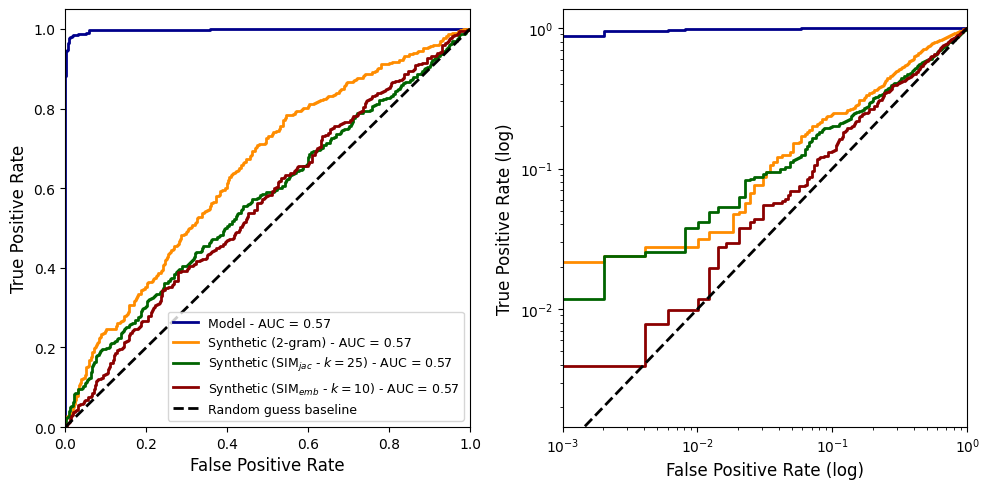

In [41]:
colors = ['darkblue', 'darkorange', 'darkgreen', 'darkred']

fig, axes = plt.subplots(1, 2, figsize = (10, 5))

for i, key in enumerate(agnews_main_urls.keys()):
    performance = main_mia_results[key]
    fpr, tpr = performance['fpr'], performance['tpr']

    axes[0].plot(fpr, tpr, lw=2, label=f'{job_names[i]} - AUC = %0.2f' % roc_auc, color = colors[i])
    axes[1].plot(fpr, tpr, lw=2, label=f'{job_names[i]} - AUC = %0.2f' % roc_auc, color=colors[i])

axes[0].plot([0, 1], [0, 1], color='black', lw=2, linestyle='--', label = 'Random guess baseline')
axes[1].plot([0, 1], [0, 1], color='black', lw=2, linestyle='--', label = 'Random guess baseline')

axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize = 12)
axes[0].set_ylabel('True Positive Rate', fontsize = 12)

axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlim([1e-3, 1e0])
axes[1].set_xlabel('False Positive Rate (log)', fontsize = 12)
axes[1].set_ylabel('True Positive Rate (log)', fontsize = 12)

axes[0].legend(loc="lower right", fontsize = 9)

plt.tight_layout()
plt.savefig('figures/tpr_fpr_all_attacks_agnews.pdf', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()